In [2]:
import pandas as pd
import numpy as np
import umap
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, rand_score
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
# Fixed seed used for BOTH the base clustering and every LOO clustering,
# so the only difference between runs is the removed point.
RANDOM_STATE = 42

FEATURES_CSV = "../data/features.csv"
RESULTS_CSV  = "loo_scores.csv"
OUTPUT_PNG   = "loo_influence_scores.png"
# ──────────────────────────────────────────────────────────────────────────────

In [3]:
# ── Load + preprocess ─────────────────────────────────────────────────────────
df_original = pd.read_csv(FEATURES_CSV)
print(f"Loaded {len(df_original)} rows, {len(df_original.columns)} columns")

def preprocess(df: pd.DataFrame) -> np.ndarray:
    """Return a scaled numpy array ready for UMAP, leaving df unchanged."""
    X = df.drop(columns=["file_name"], errors="ignore").copy()
    X = X.replace({'True': 1, 'False': 0, True: 1, False: 0})
    X = X.apply(pd.to_numeric, errors='coerce')
    all_nan_cols = X.columns[X.isna().all()].tolist()
    if all_nan_cols:
        X = X.drop(columns=all_nan_cols)
    X = X.fillna(X.mean())
    return StandardScaler().fit_transform(X)

Loaded 446 rows, 72 columns


In [4]:
# ── UMAP / HDBSCAN parameters (identical to UMAP_HDBSCAN.ipynb) ───────────────
UMAP_PARAMS = dict(
    n_neighbors  = 10,
    min_dist     = 0.001,
    n_components = 3,
    metric       = "euclidean",
    random_state = RANDOM_STATE,
)

HDBSCAN_PARAMS = dict(
    min_cluster_size = 30,
    min_samples      = 5,
    metric           = "euclidean",
)

def cluster(X_scaled: np.ndarray) -> np.ndarray:
    embedding = umap.UMAP(**UMAP_PARAMS).fit_transform(X_scaled)
    return hdbscan.HDBSCAN(**HDBSCAN_PARAMS).fit_predict(embedding)

In [5]:
# ── Base clustering (all N points) ────────────────────────────────────────────
file_names   = df_original["file_name"].values
X_full       = preprocess(df_original)
base_labels  = cluster(X_full)

n_clusters   = len(set(base_labels) - {-1})
noise_count  = np.sum(base_labels == -1)
print(f"Base clustering:  {len(base_labels)} points  |  "
      f"{n_clusters} clusters  |  {noise_count} noise points")
print(f"Label distribution: { {k: int(np.sum(base_labels==k)) for k in sorted(set(base_labels))} }")

Base clustering:  446 points  |  4 clusters  |  25 noise points
Label distribution: {np.int64(-1): 25, np.int64(0): 79, np.int64(1): 83, np.int64(2): 71, np.int64(3): 188}


In [6]:
# ── Leave-One-Out experiment ───────────────────────────────────────────────────
# For each point i:
#   1. Build df with row i removed (df_original is never modified)
#   2. Fit UMAP + HDBSCAN on the N-1 points
#   3. Compare the N-1 LOO labels against the corresponding N-1 base labels
#   4. Record RAND score, ARI, the point's base cluster, and its file_name

# Index array without each position — used to slice base_labels
N       = len(df_original)
results = []

for i in tqdm(range(N), desc="LOO fitting", unit="pt"):
    # Build N-1 dataset
    df_loo      = df_original.drop(index=i).reset_index(drop=True)
    X_loo       = preprocess(df_loo)
    loo_labels  = cluster(X_loo)

    # Base labels for the same N-1 points (drop index i)
    base_loo    = np.delete(base_labels, i)

    ari  = adjusted_rand_score(base_loo, loo_labels)
    rand = rand_score(base_loo, loo_labels)

    results.append({
        "index"        : i,
        "file_name"    : file_names[i],
        "base_cluster" : int(base_labels[i]),
        "ari"          : ari,
        "rand"         : rand,
    })

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"\nSaved results → {RESULTS_CSV}")
print(results_df[["file_name", "base_cluster", "ari", "rand"]]
      .sort_values("ari")
      .head(15)
      .to_string(index=False))

LOO fitting:   0%|          | 0/446 [00:00<?, ?pt/s]


Saved results → loo_scores.csv
                                  file_name  base_cluster      ari     rand
 MATLAB 12-29 PM Tue, Apr 2, 2024 Run3 .csv             0 0.613649 0.869015
 MATLAB 4-05 PM Thu, Oct 3, 2024 Run13 .csv             3 0.665905 0.885494
  MATLAB 3-29 PM Tue, Oct 8, 2024 Run9 .csv             3 0.693536 0.894159
  MATLAB 2-46 PM Tue, Oct 8, 2024 Run2 .csv             1 0.696893 0.894858
 MATLAB 1-02 PM Mon, Mar 11, 2024 Run4 .csv             0 0.707216 0.893036
MATLAB 1-21 PM Tue, Sep 10, 2024 Run13 .csv             2 0.707298 0.897287
 MATLAB 12-28 PM Thu, Nov 7, 2024 Run5 .csv             3 0.714560 0.900577
 MATLAB 1-04 PM Tue, Sep 10, 2024 Run9 .csv             2 0.714723 0.900294
  MATLAB 4-02 PM Thu, Sep 5, 2024 Run2 .csv             2 0.744078 0.909424
 MATLAB 3-33 PM Tue, Oct 8, 2024 Run10 .csv             3 0.745988 0.910325
 MATLAB 3-02 PM Fri, Aug 23, 2024 Run3 .csv             2 0.747773 0.910649
 MATLAB 3-02 PM Thu, Oct 17, 2024 Run2 .csv             

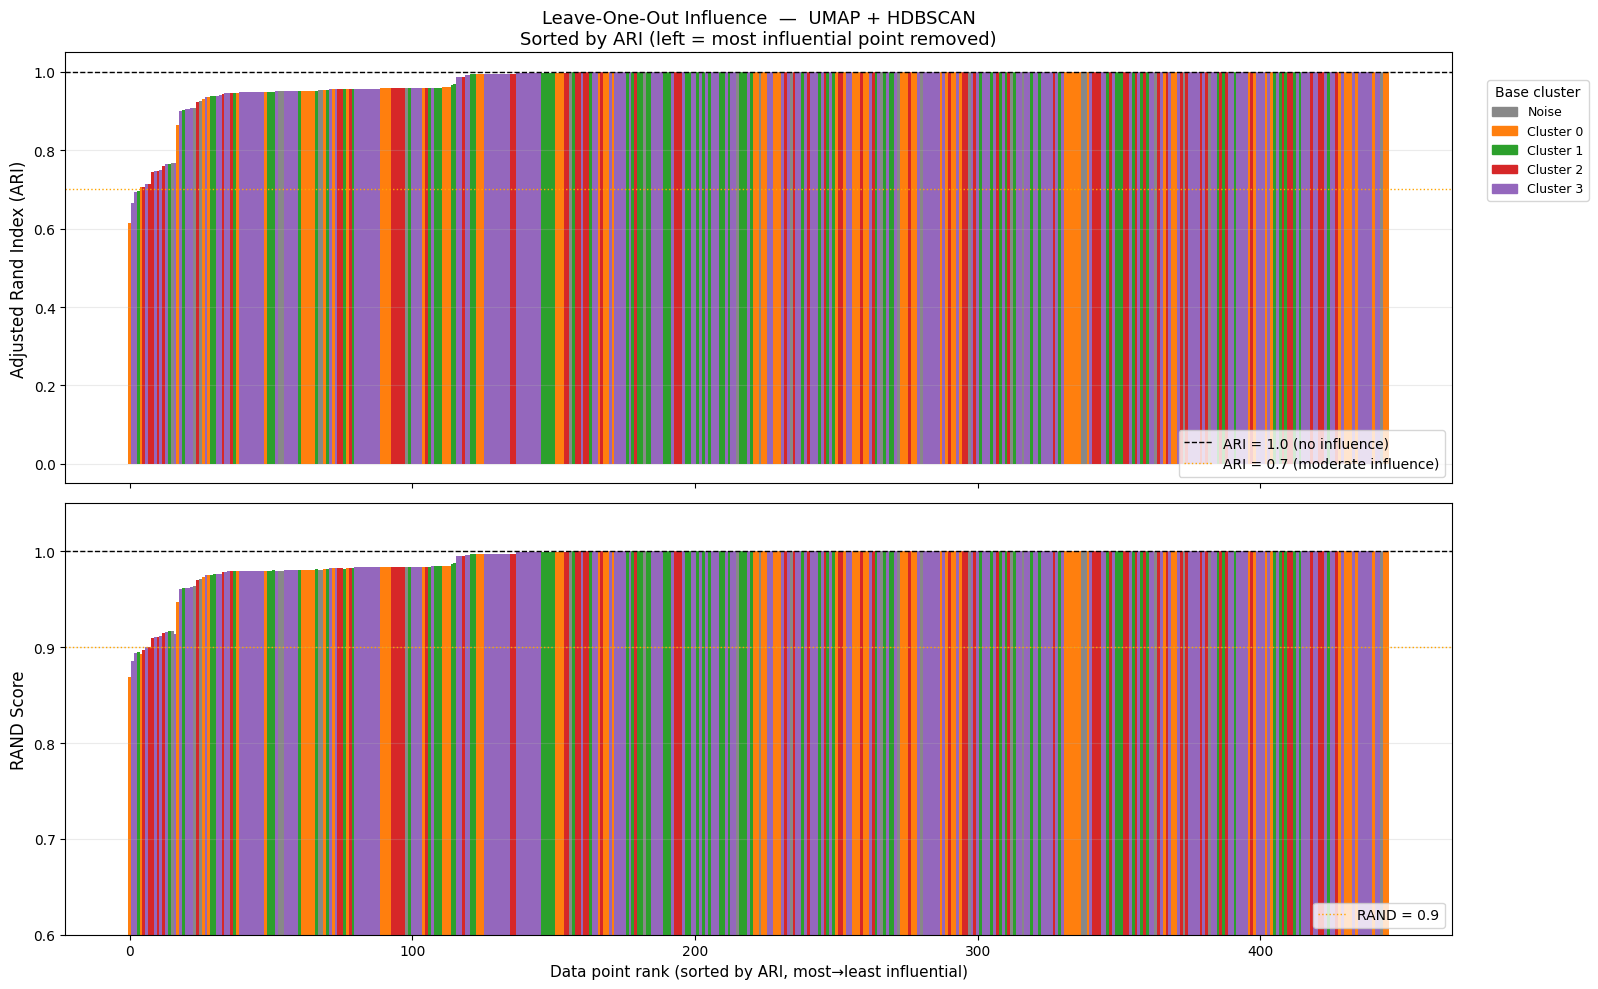

Saved plot → loo_influence_scores.png


In [7]:
# ── Visualization ─────────────────────────────────────────────────────────────
# Sort by ARI ascending → most influential points on the left.
# Each bar is coloured by the point's base cluster assignment.
# Noise points (cluster = -1) are shown in grey.

df_plot = results_df.sort_values("ari").reset_index(drop=True)

unique_clusters = sorted(df_plot["base_cluster"].unique())
cmap   = plt.get_cmap("tab10")
colors = {
    cl: ("#888888" if cl == -1 else cmap(i % 10))
    for i, cl in enumerate(unique_clusters)
}
bar_colors = [colors[cl] for cl in df_plot["base_cluster"]]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ── Top panel: ARI ────────────────────────────────────────────────────────────
axes[0].bar(range(len(df_plot)), df_plot["ari"], color=bar_colors, width=1.0, linewidth=0)
axes[0].axhline(1.0, color="black",  linewidth=1.0, linestyle="--", label="ARI = 1.0 (no influence)")
axes[0].axhline(0.7, color="orange", linewidth=1.0, linestyle=":",  label="ARI = 0.7 (moderate influence)")
axes[0].set_ylabel("Adjusted Rand Index (ARI)", fontsize=12)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title(
    "Leave-One-Out Influence  —  UMAP + HDBSCAN\n"
    "Sorted by ARI (left = most influential point removed)",
    fontsize=13,
)
axes[0].legend(fontsize=10, loc="lower right")
axes[0].grid(axis="y", alpha=0.25)

# ── Bottom panel: RAND ────────────────────────────────────────────────────────
axes[1].bar(range(len(df_plot)), df_plot["rand"], color=bar_colors, width=1.0, linewidth=0)
axes[1].axhline(1.0, color="black",  linewidth=1.0, linestyle="--")
axes[1].axhline(0.9, color="orange", linewidth=1.0, linestyle=":",  label="RAND = 0.9")
axes[1].set_ylabel("RAND Score", fontsize=12)
axes[1].set_ylim(0.6, 1.05)
axes[1].set_xlabel("Data point rank (sorted by ARI, most→least influential)", fontsize=11)
axes[1].legend(fontsize=10, loc="lower right")
axes[1].grid(axis="y", alpha=0.25)

# ── Shared legend for cluster colours ────────────────────────────────────────
patches = [
    mpatches.Patch(color=colors[cl], label=("Noise" if cl == -1 else f"Cluster {cl}"))
    for cl in unique_clusters
]
fig.legend(
    handles=patches, title="Base cluster",
    loc="upper right", bbox_to_anchor=(1.0, 0.92),
    fontsize=9, title_fontsize=10,
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved plot → {OUTPUT_PNG}")

In [8]:
# ── Summary statistics ────────────────────────────────────────────────────────
print("=== Overall summary ===")
print(results_df[["ari", "rand"]].describe().round(4))

print("\n=== Most influential points (ARI < 0.7) ===")
influential = results_df[results_df["ari"] < 0.7].sort_values("ari")
if influential.empty:
    print("None — all points have ARI ≥ 0.7")
else:
    print(influential[["file_name", "base_cluster", "ari", "rand"]].to_string(index=False))

print("\n=== Per-cluster mean ARI ===")
print(
    results_df.groupby("base_cluster")[["ari", "rand"]]
    .mean().round(4)
    .rename(columns={"ari": "mean_ari", "rand": "mean_rand"})
)

=== Overall summary ===
            ari      rand
count  446.0000  446.0000
mean     0.9776    0.9916
std      0.0557    0.0199
min      0.6136    0.8690
25%      0.9603    0.9846
50%      1.0000    1.0000
75%      1.0000    1.0000
max      1.0000    1.0000

=== Most influential points (ARI < 0.7) ===
                                 file_name  base_cluster      ari     rand
MATLAB 12-29 PM Tue, Apr 2, 2024 Run3 .csv             0 0.613649 0.869015
MATLAB 4-05 PM Thu, Oct 3, 2024 Run13 .csv             3 0.665905 0.885494
 MATLAB 3-29 PM Tue, Oct 8, 2024 Run9 .csv             3 0.693536 0.894159
 MATLAB 2-46 PM Tue, Oct 8, 2024 Run2 .csv             1 0.696893 0.894858

=== Per-cluster mean ARI ===
              mean_ari  mean_rand
base_cluster                     
-1              0.9745     0.9902
 0              0.9773     0.9914
 1              0.9820     0.9932
 2              0.9728     0.9901
 3              0.9779     0.9917
